# LightGBM Solar Power Prediction using ERA5 features

This notebook trains LightGBM models using ERA5 reanalysis weather features for solar power prediction in Spain. We compare:
1. Default model (all hours)
2. Daytime-only model (solar elevation > 0)

   Training: Filter data when solar_elevation > 0 & train the model

   Prediction:
    - if solar_elevation > 0: prediction = model.predict(features)
    - else: prediction = 0  # no solar output
3. Optuna-tuned model (hyperparameter optimization)

Against the day-ahead forecast baseline.

## 1. Imports & ERA features

In [1]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Configuration
DATA_DIR = "data"
INPUT_FILE = os.path.join(DATA_DIR, "era5_features_merged.csv")
OUTPUT_DIR = os.path.join("output", "results", "LightGBM_ERA5")

TARGET_COL = "generation solar"
FORECAST_COL = "forecast solar day ahead"
TRAIN_FRAC = 0.70
SEED = 42

TIME_FEATURES = [
    'month', 'day_of_year', 'date_fraction_of_year', 'day_of_week',
    'is_weekend', 'season', 'is_holiday', 'utc_time_day_fraction',
    'day_hour_sin', 'day_hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'day_of_year_sin', 'day_of_year_cos', 'month_sin', 'month_cos'
]

# ERA5 reanalysis features (built in era5_feature_engineering.py)
ERA5_FEATURES = [
    "era5_ghi_wm2", "era5_clearsky_ghi_wm2", "era5_clearsky_index",
    "era5_tcc", "era5_lcc", "era5_mcc", "era5_hcc", "era5_cloud_clearness",
    "era5_t2m", "era5_d2m", "era5_dewpoint_depression",
    "era5_pressure_hpa", "era5_wind_speed_10m", "era5_wind_dir_10m",
    "era5_precip_mm", "era5_blh", "era5_temp_irradiance_interaction",
    # Rolling (shift(1) applied in era5_feature_engineering.py — no leakage)
    "era5_ghi_wm2_rolling3h", "era5_clearsky_index_rolling3h",
    "era5_tcc_rolling3h", "era5_t2m_rolling3h", "era5_pressure_hpa_rolling3h",
    "era5_wind_speed_10m_rolling3h", "era5_precip_mm_rolling3h", "era5_blh_rolling3h",
    # Per-plant (unweighted, for spatial learning)
    "era5_andasol_ghi_wm2", "era5_andasol_clearsky_index", "era5_andasol_tcc", "era5_andasol_t2m",
    "era5_gemasolar_ghi_wm2", "era5_gemasolar_clearsky_index", "era5_gemasolar_tcc", "era5_gemasolar_t2m",
    "era5_olmedilla_ghi_wm2", "era5_olmedilla_clearsky_index", "era5_olmedilla_tcc", "era5_olmedilla_t2m",
    "era5_puertollano_ghi_wm2", "era5_puertollano_clearsky_index", "era5_puertollano_tcc", "era5_puertollano_t2m",
    "era5_extremadura_ghi_wm2", "era5_extremadura_clearsky_index", "era5_extremadura_tcc", "era5_extremadura_t2m",
    # Spatial dispersion (std across plants — low = uniform conditions)
    "era5_ghi_wm2_spatial_std", "era5_tcc_spatial_std",
]

print(f"Time features: {len(TIME_FEATURES)}")
print(f"ERA5 features: {len(ERA5_FEATURES)}")

Time features: 16
ERA5 features: 47


## 2. Metric Functions

In [2]:
def smape(y_true, y_pred):
    """Symmetric Mean Absolute Percentage Error"""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    mask = (denom != 0) & np.isfinite(denom) & np.isfinite(diff)
    if not np.any(mask):
        return np.nan
    return np.mean(diff[mask] / denom[mask]) * 100.0


def safe_metrics(y_true, y_pred):
    """Compute metrics with NaN/inf filtering."""
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if not np.any(mask):
        return {k: np.nan for k in ["MSE", "RMSE", "MAE", "MAPE", "sMAPE", "R2"]}
    yt, yp = y_true[mask], y_pred[mask]
    return {
        "MSE": mean_squared_error(yt, yp),
        "RMSE": np.sqrt(mean_squared_error(yt, yp)),
        "MAE": mean_absolute_error(yt, yp),
        "MAPE": mean_absolute_percentage_error(yt, yp) * 100.0,
        "sMAPE": smape(yt, yp),
        "R2": r2_score(yt, yp),
    }


def rmse_skill(y_true, y_model, y_bench):
    """Calculate RMSE skill score vs benchmark."""
    rmse_m = np.sqrt(mean_squared_error(y_true, y_model))
    rmse_b = np.sqrt(mean_squared_error(y_true, y_bench))
    return 1.0 - (rmse_m / rmse_b) if rmse_b > 0 else np.nan

## 3. Time Feature Engineering

In [3]:
def add_time_features(df, datetime_col="utc_time"):
    """Add cyclical and calendar time features."""
    import holidays as holidays_lib
    from suntime import Sun
    from datetime import datetime, timezone

    dt = pd.to_datetime(df[datetime_col])
    df = df.copy()

    # Calendar features
    df["month"] = dt.dt.month
    df["day_of_year"] = dt.dt.dayofyear
    df["date_fraction_of_year"] = df["day_of_year"] / 365.25
    df["day_of_week"] = dt.dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    # Season (0=winter, 1=spring, 2=summer, 3=autumn)
    def get_season(m):
        if m in [3, 4, 5]:
            return 1
        elif m in [6, 7, 8]:
            return 2
        elif m in [9, 10, 11]:
            return 3
        return 0
    df["season"] = df["month"].apply(get_season)

    # Spanish holidays
    years = dt.dt.year.unique().tolist()
    es_holidays = holidays_lib.country_holidays("ES", years=years)
    df["is_holiday"] = dt.dt.date.isin(es_holidays).astype(int)

    # Cyclical time encodings
    df["utc_time_day_fraction"] = dt.dt.hour / 24.0 + dt.dt.minute / 1440.0
    df["day_hour_sin"] = np.sin(2 * np.pi * dt.dt.hour / 24)
    df["day_hour_cos"] = np.cos(2 * np.pi * dt.dt.hour / 24)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
    df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Sunrise/sunset (center of Spain: 38.4°N, 4.2°W)
    sun = Sun(38.4, -4.2)
    dates = dt.dt.date.unique()
    sun_records = {}
    for d in dates:
        try:
            dt_utc = datetime.combine(d, datetime.min.time()).replace(tzinfo=timezone.utc)
            sunrise = sun.get_sunrise_time(dt_utc)
            sunset = sun.get_sunset_time(dt_utc)
            sr_frac = sunrise.hour / 24 + sunrise.minute / 1440
            ss_frac = sunset.hour / 24 + sunset.minute / 1440
            dl_hr = (sunset - sunrise).total_seconds() / 3600
            if dl_hr < 0:
                dl_hr += 24
            sun_records[d] = (sr_frac, ss_frac, dl_hr)
        except Exception:
            sun_records[d] = (np.nan, np.nan, np.nan)

    df["sunrise_day_fraction_utc"] = dt.dt.date.map(lambda d: sun_records.get(d, (np.nan,))[0])
    df["sunset_day_fraction_utc"] = dt.dt.date.map(lambda d: sun_records.get(d, (np.nan, np.nan))[1])
    df["daylight_length_hr"] = dt.dt.date.map(lambda d: sun_records.get(d, (np.nan, np.nan, np.nan))[2])

    return df

## 4. Load and Prepare Data

In [4]:
# Load ERA5 data (merged with energy data in era5_feature_engineering.py)
print(f"Loading {INPUT_FILE} ...")
df = pd.read_csv(INPUT_FILE, parse_dates=["utc_time"])
df = df.sort_values("utc_time").reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Date range: {df['utc_time'].min()} to {df['utc_time'].max()}")

era5_cols_available = [c for c in df.columns if c.startswith('era5_')]
non_era5_cols = [c for c in df.columns if not c.startswith('era5_')]
print(f"\nERA5 features available: {len(era5_cols_available)}")
print(f"Other columns: {non_era5_cols[:10]}...")

df.head()

Loading data\era5_features_merged.csv ...
Shape: (35063, 76)
Date range: 2015-01-01 00:00:00 to 2018-12-31 22:00:00

ERA5 features available: 47
Other columns: ['utc_time', 'generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal']...


,utc_time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,era5_ghi_wm2_spatial_std,era5_tcc_spatial_std,era5_ghi_wm2_rolling3h,era5_clearsky_index_rolling3h,era5_tcc_rolling3h,era5_t2m_rolling3h,era5_pressure_hpa_rolling3h,era5_wind_speed_10m_rolling3h,era5_precip_mm_rolling3h,era5_blh_rolling3h
0,2015-01-01 00:00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,273.952271,951.575012,1.654457,0.0,31.265045
1,2015-01-01 01:00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,273.952271,951.575012,1.654457,0.0,31.265045
2,2015-01-01 02:00:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,273.786514,951.563324,1.604313,0.0,29.923283
3,2015-01-01 03:00:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,273.535400,951.553385,1.588092,0.0,29.428642
4,2015-01-01 04:00:00,410.0,178.0,0.0,4038.0,3590.0,156.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,273.118500,951.619507,1.557005,0.0,28.871675


In [5]:
print("Adding time features ...")
df = add_time_features(df, "utc_time")

available_era5 = [c for c in ERA5_FEATURES if c in df.columns]
available_time = [c for c in TIME_FEATURES if c in df.columns]
feature_cols = available_era5 + available_time

# Solar elevation angle (pvlib, center of Spain: 38.4N, 4.2W)
from pvlib.solarposition import get_solarposition
times_utc = pd.DatetimeIndex(df["utc_time"]).tz_localize("UTC")
solpos = get_solarposition(times_utc, 38.4, -4.2)
df["solar_elevation"] = solpos["elevation"].values
df["solar_elevation"] = df["solar_elevation"].clip(lower=-5)
feature_cols.append("solar_elevation")

print(f"\nFeatures: {len(available_era5)} ERA5 + {len(available_time)} time + 1 solar_elevation = {len(feature_cols)} total")

Adding time features ...

Features: 47 ERA5 + 16 time + 1 solar_elevation = 64 total


In [6]:
data = df[["utc_time", TARGET_COL, FORECAST_COL] + feature_cols].dropna().copy()
print(f"Rows after dropna: {len(data)}")

data["is_daytime"] = (data["solar_elevation"] > 0).astype(int)
n_day = data["is_daytime"].sum()
n_night = len(data) - n_day
print(f"Daytime hours: {n_day}, Nighttime hours: {n_night}")

cat_cols = [c for c in ["month", "day_of_week"] if c in data.columns]
for c in cat_cols:
    data[c] = data[c].astype("category")

print(f"Total features: {len(feature_cols)}")

Rows after dropna: 35045
Daytime hours: 17532, Nighttime hours: 17513
Total features: 64


## 5. Train/Test Split

In [7]:
# Chronological train/test split
N = len(data)
split_idx = int(N * TRAIN_FRAC)
train = data.iloc[:split_idx].copy()
test = data.iloc[split_idx:].copy()

train = train.set_index("utc_time", drop=False)
test = test.set_index("utc_time", drop=False)

y_train = train[TARGET_COL]
X_train = train[feature_cols]
y_test = test[TARGET_COL]
X_test = test[feature_cols]
forecast_test = test[FORECAST_COL]

print(f"Train: {len(train)} rows ({train['utc_time'].min()} to {train['utc_time'].max()})")
print(f"Test:  {len(test)} rows ({test['utc_time'].min()} to {test['utc_time'].max()})")

# Daytime masks
day_mask_train = train["is_daytime"] == 1
day_mask_test = test["is_daytime"] == 1
print(f"Daytime training rows: {day_mask_train.sum()}")

Train: 24531 rows (2015-01-01 00:00:00 to 2017-10-19 19:00:00)
Test:  10514 rows (2017-10-19 20:00:00 to 2018-12-31 22:00:00)
Daytime training rows: 12440


## 6. Train Default LightGBM Model (All Hours)

In [8]:
def train_model(X_train, y_train, cat_cols, params=None):
    """Train LightGBM with early stopping."""
    val_frac = 0.2
    val_cut = int(len(X_train) * (1 - val_frac))

    X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
    X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

    fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
    val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

    if params is None:
        params = dict(
            objective="regression",
            boosting_type="gbdt",
            metric="rmse",
            learning_rate=0.05,
            num_leaves=64,
            max_depth=-1,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            min_data_in_leaf=50,
            bagging_freq=1,
            seed=SEED,
            verbosity=-1,
            n_jobs=-1,
        )

    model = lgb.train(
        params=params,
        train_set=fit_set,
        num_boost_round=5000,
        valid_sets=[fit_set, val_set],
        valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(stopping_rounds=200), lgb.log_evaluation(200)],
    )
    print(f"Best iteration: {model.best_iteration}")
    return model

In [9]:
print("Training ERA5 LightGBM (default params, all hours) ...")
model_default = train_model(X_train, y_train, cat_cols)
y_pred_default = model_default.predict(X_test, num_iteration=model_default.best_iteration)

Training ERA5 LightGBM (default params, all hours) ...
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 267.301	val's rmse: 665.132
Early stopping, best iteration is:
[110]	train's rmse: 373.139	val's rmse: 662.809
Best iteration: 110


## 7. Train Daytime-Only LightGBM Model

In [10]:
# Filter to daytime only
X_train_day = X_train[day_mask_train]
y_train_day = y_train[day_mask_train]

print("Training ERA5 LightGBM (daytime-only) ...")
print(f"Daytime training rows: {len(X_train_day)}")
model_day = train_model(X_train_day, y_train_day, cat_cols)

# Predict: 0 for nighttime, model prediction for daytime
y_pred_day = np.zeros(len(y_test))
if day_mask_test.any():
    y_pred_day[day_mask_test.values] = model_day.predict(
        X_test[day_mask_test], num_iteration=model_day.best_iteration
    )
y_pred_day = np.clip(y_pred_day, 0, None)  # No negative predictions

Training ERA5 LightGBM (daytime-only) ...
Daytime training rows: 12440
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 322.012	val's rmse: 863.425
Early stopping, best iteration is:
[95]	train's rmse: 539.85	val's rmse: 847.798
Best iteration: 95


## 8. Optuna Hyperparameter Tuning

In [11]:
def optuna_tune(X_train, y_train, cat_cols, n_trials=40):
    """Optuna hyperparameter optimization."""
    print(f"Optuna tuning ({n_trials} trials) ...")

    # Validation split
    val_cut = int(len(X_train) * 0.8)
    X_tr, y_tr = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
    X_val, y_val = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

    fit_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_cols or None, free_raw_data=False)
    val_set = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_cols or None, free_raw_data=False)

    def objective(trial):
        params = dict(
            objective="regression",
            boosting_type="gbdt",
            metric="rmse",
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            num_leaves=trial.suggest_int("num_leaves", 16, 512),
            max_depth=trial.suggest_int("max_depth", 3, 15),
            min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 10, 300),
            feature_fraction=trial.suggest_float("feature_fraction", 0.4, 1.0),
            bagging_fraction=trial.suggest_float("bagging_fraction", 0.4, 1.0),
            bagging_freq=trial.suggest_int("bagging_freq", 0, 5),
            lambda_l1=trial.suggest_float("lambda_l1", 1e-4, 10.0, log=True),
            lambda_l2=trial.suggest_float("lambda_l2", 1e-4, 10.0, log=True),
            seed=SEED,
            verbosity=-1,
            n_jobs=-1,
        )
        model = lgb.train(
            params=params,
            train_set=fit_set,
            num_boost_round=3000,
            valid_sets=[val_set],
            valid_names=["val"],
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)],
        )
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        return np.sqrt(mean_squared_error(y_val, preds))

    study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=SEED))
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"Best RMSE: {study.best_value:.2f}")
    print(f"Best params: {study.best_params}")

    # Retrain with best params
    best_params = dict(
        objective="regression",
        boosting_type="gbdt",
        metric="rmse",
        seed=SEED,
        verbosity=-1,
        n_jobs=-1,
        **study.best_params,
    )
    best_model = lgb.train(
        params=best_params,
        train_set=fit_set,
        num_boost_round=3000,
        valid_sets=[fit_set, val_set],
        valid_names=["train", "val"],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)],
    )
    return best_model, study

In [12]:
# Run Optuna tuning on daytime data
model_tuned, study = optuna_tune(X_train_day, y_train_day, cat_cols, n_trials=40)

# Generate predictions
y_pred_tuned = np.zeros(len(y_test))
if day_mask_test.any():
    y_pred_tuned[day_mask_test.values] = model_tuned.predict(
        X_test[day_mask_test], num_iteration=model_tuned.best_iteration
    )
y_pred_tuned = np.clip(y_pred_tuned, 0, None)

[I 2026-02-18 19:36:25,602] A new study created in memory with name: no-name-1fe05224-4cf8-4e18-90ac-6f64bab88e78


Optuna tuning (40 trials) ...


  0%|          | 0/40 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[169]	val's rmse: 862.692
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[83]	val's rmse: 878.077
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[148]	val's rmse: 844.274
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[326]	val's rmse: 880.214
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[214]	val's rmse: 848.675
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[93]	val's rmse: 862.827
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[272]	val's rmse: 855.753
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[233]	val's rmse: 854.207
Training until val

## 9. Evaluate and Compare Models

In [13]:
y_true = y_test.values
y_forecast = forecast_test.values

# Compute metrics for all models
metrics = {
    "ERA5 (all hours)": safe_metrics(y_true, y_pred_default),
    "ERA5 (day only)": safe_metrics(y_true, y_pred_day),
    "ERA5 (day+tuned)": safe_metrics(y_true, y_pred_tuned),
    "Day-Ahead Forecast": safe_metrics(y_true, y_forecast),
}

# Add RMSE skill scores
metrics["ERA5 (all hours)"]["RMSE Skill"] = rmse_skill(y_true, y_pred_default, y_forecast)
metrics["ERA5 (day only)"]["RMSE Skill"] = rmse_skill(y_true, y_pred_day, y_forecast)
metrics["ERA5 (day+tuned)"]["RMSE Skill"] = rmse_skill(y_true, y_pred_tuned, y_forecast)
metrics["Day-Ahead Forecast"]["RMSE Skill"] = 0.0

# Display comparison table
df_metrics = pd.DataFrame(metrics)
print("=" * 80)
print("MODEL COMPARISON — Solar Power Prediction (Test Set)")
print("=" * 80)
df_metrics.round(3)

MODEL COMPARISON — Solar Power Prediction (Test Set)


,ERA5 (all hours),ERA5 (day only),ERA5 (day+tuned),Day-Ahead Forecast
MSE,3.936846e+05,4.662479e+05,4.386348e+05,4.670707e+04
RMSE,6.274430e+02,6.828230e+02,6.622950e+02,2.161180e+02
MAE,3.744360e+02,4.102420e+02,3.955360e+02,1.301400e+02
MAPE,1.880185e+17,1.628095e+17,1.716228e+17,1.922832e+17
sMAPE,6.378200e+01,1.198490e+02,1.193350e+02,3.696700e+01
R2,8.540000e-01,8.270000e-01,8.380000e-01,9.830000e-01
RMSE Skill,-1.903000e+00,-2.159000e+00,-2.065000e+00,0.000000e+00


## 10. Error vs Time Analysis

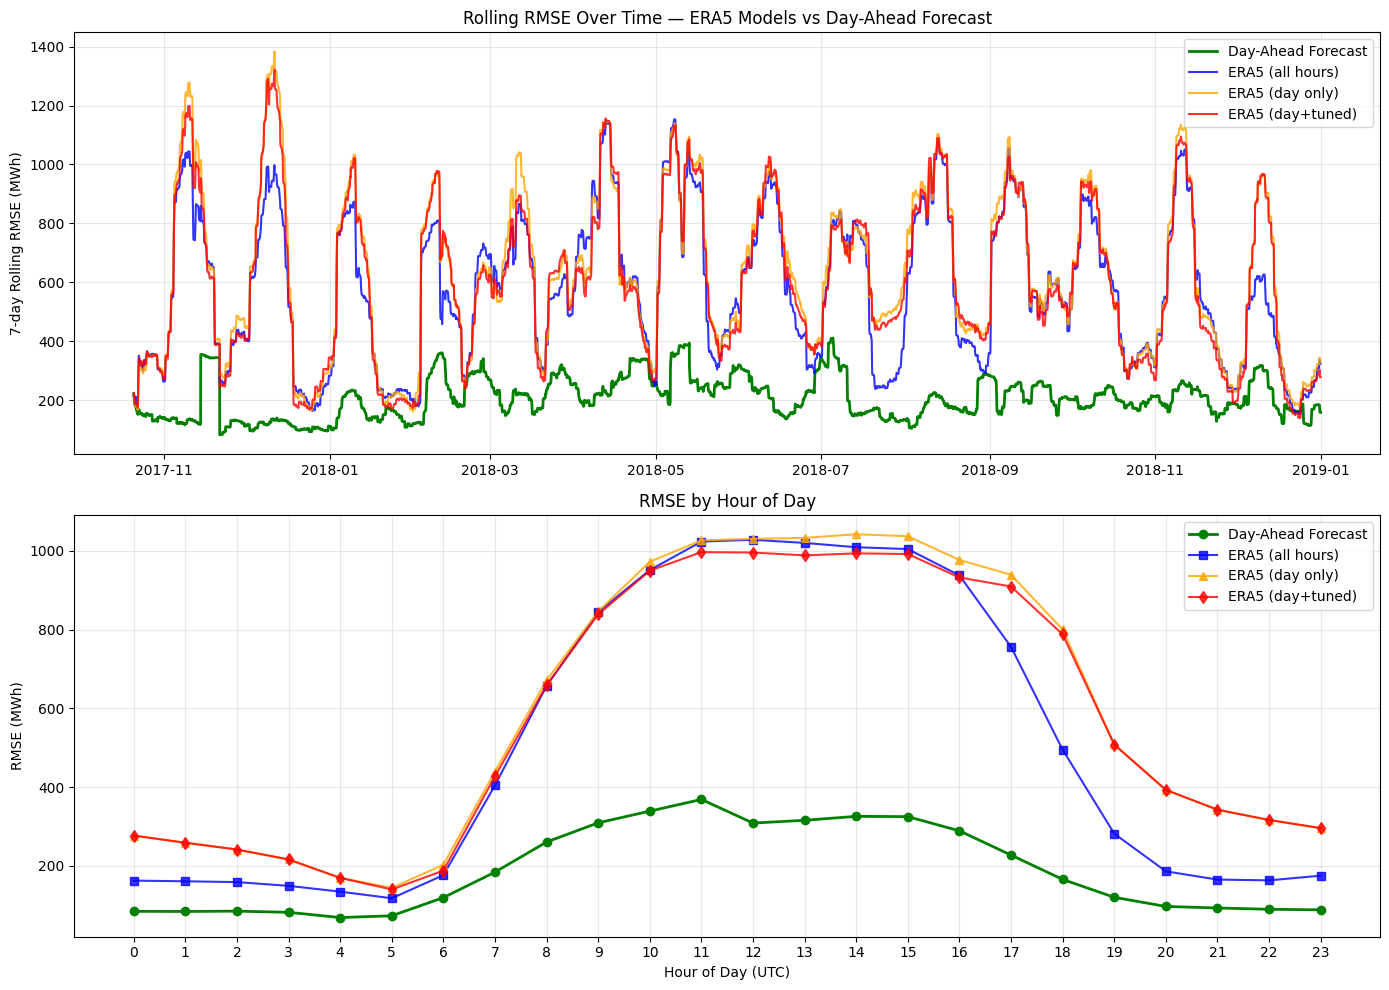

Peak hours (10-16 UTC):
  ERA5 (all hours): RMSE=997
  ERA5 (day only): RMSE=1018
  ERA5 (day+tuned): RMSE=979
  Day-Ahead Forecast: RMSE=326

--- Solar_prediction_LightGBM_Spain reference ---
  All test:     LightGBM RMSE=657, Forecast RMSE=216
  Peak (10-16): LightGBM RMSE=1053, Forecast RMSE=326 (3.2x worse)


In [14]:
import matplotlib.pyplot as plt

test_times = pd.to_datetime(test["utc_time"].values)
err_df = pd.DataFrame({
    "utc_time": test_times,
    "hour": test_times.hour,
    "sq_default":  (y_true - y_pred_default) ** 2,
    "sq_day":      (y_true - y_pred_day) ** 2,
    "sq_tuned":    (y_true - y_pred_tuned) ** 2,
    "sq_forecast": (y_true - y_forecast) ** 2,
})

# 7-day rolling RMSE (same window as Solar_prediction_LightGBM_Spain)
W = 24 * 7
for col in ["sq_default", "sq_day", "sq_tuned", "sq_forecast"]:
    err_df[f"roll_{col}"] = np.sqrt(err_df[col].rolling(W, min_periods=24).mean())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Rolling RMSE over time
ax1.plot(err_df["utc_time"], err_df["roll_sq_forecast"], label="Day-Ahead Forecast", color="green", linewidth=2)
ax1.plot(err_df["utc_time"], err_df["roll_sq_default"], label="ERA5 (all hours)", color="blue", alpha=0.8)
ax1.plot(err_df["utc_time"], err_df["roll_sq_day"],     label="ERA5 (day only)", color="orange", alpha=0.8)
ax1.plot(err_df["utc_time"], err_df["roll_sq_tuned"],   label="ERA5 (day+tuned)", color="red", alpha=0.8)
ax1.set_ylabel("7-day Rolling RMSE (MWh)")
ax1.set_title("Rolling RMSE Over Time \u2014 ERA5 Models vs Day-Ahead Forecast")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: RMSE by hour of day
hourly = err_df.groupby("hour").agg(
    default=("sq_default",  lambda x: np.sqrt(x.mean())),
    day=("sq_day",          lambda x: np.sqrt(x.mean())),
    tuned=("sq_tuned",      lambda x: np.sqrt(x.mean())),
    forecast=("sq_forecast", lambda x: np.sqrt(x.mean())),
).reset_index()

ax2.plot(hourly["hour"], hourly["forecast"], "g-o",  label="Day-Ahead Forecast", linewidth=2)
ax2.plot(hourly["hour"], hourly["default"],  "b-s",  label="ERA5 (all hours)", alpha=0.8)
ax2.plot(hourly["hour"], hourly["day"],      "-^",   color="orange", label="ERA5 (day only)", alpha=0.8)
ax2.plot(hourly["hour"], hourly["tuned"],    "r-d",  label="ERA5 (day+tuned)", alpha=0.8)
ax2.set_xlabel("Hour of Day (UTC)")
ax2.set_ylabel("RMSE (MWh)")
ax2.set_title("RMSE by Hour of Day")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

# Peak hours (10-16 UTC) — same window as Solar_prediction analysis
peak = err_df["hour"].between(10, 16)
print("Peak hours (10-16 UTC):")
for name, col in [("ERA5 (all hours)", "sq_default"), ("ERA5 (day only)", "sq_day"),
                   ("ERA5 (day+tuned)", "sq_tuned"), ("Day-Ahead Forecast", "sq_forecast")]:
    print(f"  {name}: RMSE={np.sqrt(err_df.loc[peak, col].mean()):.0f}")

# Comparison with Solar_prediction_LightGBM_Spain
print("\n--- Solar_prediction_LightGBM_Spain reference ---")
print("  All test:     LightGBM RMSE=657, Forecast RMSE=216")
print("  Peak (10-16): LightGBM RMSE=1053, Forecast RMSE=326 (3.2x worse)")

## 11. Feature Importance Analysis

In [15]:
# Extract feature importance from tuned model
feat_names = model_tuned.feature_name()
imp_gain = model_tuned.feature_importance(importance_type="gain")
imp_split = model_tuned.feature_importance(importance_type="split")

fi_df = (
    pd.DataFrame({"feature": feat_names, "gain": imp_gain, "split": imp_split})
    .assign(gain_pct=lambda d: 100 * d["gain"] / d["gain"].sum() if d["gain"].sum() > 0 else 0)
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 Features by Gain (Tuned Model):")
fi_df.head(20)

Top 20 Features by Gain (Tuned Model):


,feature,gain,split,gain_pct
0,era5_clearsky_ghi_wm2,4.933755e+10,272,19.364663
1,era5_puertollano_ghi_wm2,2.664942e+10,81,10.459721
2,era5_olmedilla_ghi_wm2,1.738307e+10,103,6.822741
3,era5_ghi_wm2,1.731447e+10,81,6.795814
4,solar_elevation,1.672019e+10,176,6.562566
5,day_of_year,1.502968e+10,848,5.899050
6,day_of_year_sin,1.375127e+10,984,5.397282
7,day_of_year_cos,1.000742e+10,668,3.927847
8,era5_tcc_rolling3h,6.791570e+09,253,2.665646
9,date_fraction_of_year,5.662424e+09,335,2.222464


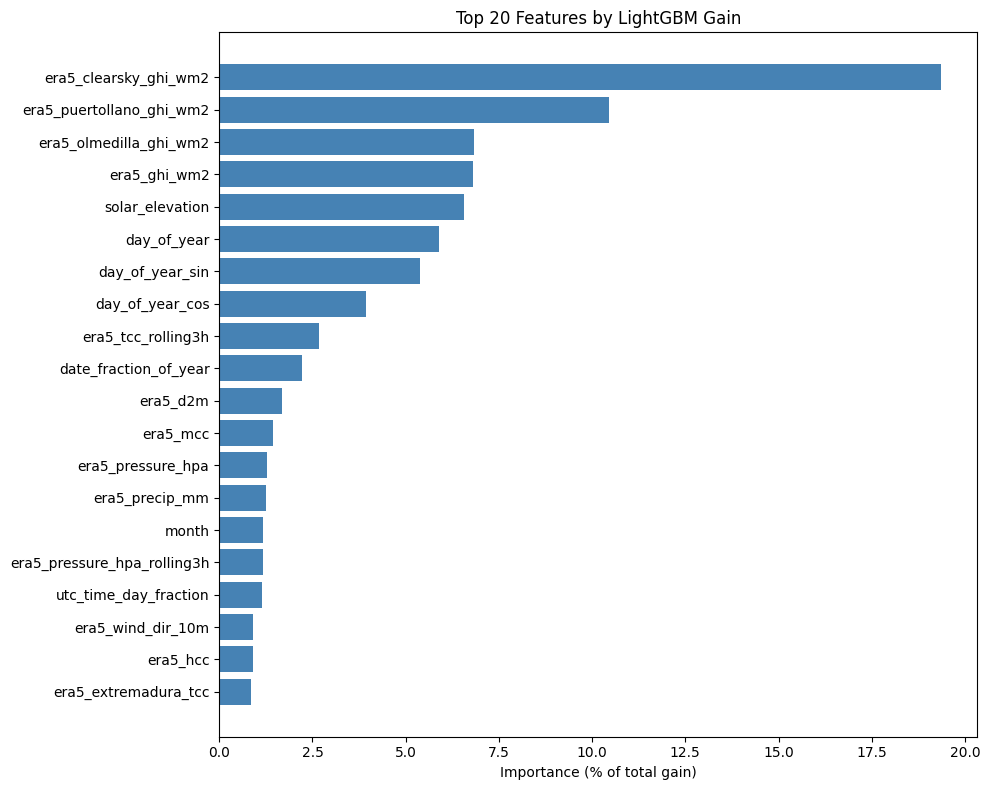

In [16]:
# Visualize top features
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
top_20 = fi_df.head(20).iloc[::-1]  # Reverse for horizontal bar
ax.barh(top_20["feature"], top_20["gain_pct"], color="steelblue")
ax.set_xlabel("Importance (% of total gain)")
ax.set_title("Top 20 Features by LightGBM Gain")
plt.tight_layout()
plt.show()

## 12. Save Results

In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save metrics
csv_path = os.path.join(OUTPUT_DIR, "era5_model_comparison_metrics.csv")
df_metrics.to_csv(csv_path)
print(f"Metrics saved to: {csv_path}")

# Save feature importance
fi_path = os.path.join(OUTPUT_DIR, "era5_feature_importance.csv")
fi_df.to_csv(fi_path, index=False)
print(f"Feature importance saved to: {fi_path}")

# Save Optuna study
study_path = os.path.join(OUTPUT_DIR, "optuna_study_results.csv")
study.trials_dataframe().to_csv(study_path, index=False)
print(f"Optuna study saved to: {study_path}")

# Save markdown summary
md_path = os.path.join(OUTPUT_DIR, "era5_model_comparison.md")
with open(md_path, "w", encoding="utf-8") as f:
    f.write("# ERA5-Enhanced Solar Power Prediction — Model Comparison\n\n")
    f.write("## Metrics (Test Set)\n\n")
    f.write(df_metrics.round(3).to_string())
    f.write("\n\n## Top 20 Features (Tuned Model)\n\n")
    f.write(fi_df.head(20).to_string(index=False))
    f.write("\n\n## Optuna Best Parameters\n\n")
    f.write(f"```\n{study.best_params}\n```\n")
print(f"Summary saved to: {md_path}")

print("\n" + "=" * 50)
print("DONE — ERA5-enhanced model training complete!")
print("=" * 50)

Metrics saved to: output\results\LightGBM_ERA5\era5_model_comparison_metrics.csv
Feature importance saved to: output\results\LightGBM_ERA5\era5_feature_importance.csv
Optuna study saved to: output\results\LightGBM_ERA5\optuna_study_results.csv
Summary saved to: output\results\LightGBM_ERA5\era5_model_comparison.md

DONE — ERA5-enhanced model training complete!
